In [1]:
import kagglehub

path = kagglehub.dataset_download(
    "kaustubhdikshit/neu-surface-defect-database"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
Path to dataset files: /kaggle/input/neu-surface-defect-database


In [2]:
!pip install ultralytics opencv-python numpy tqdm scikit-fuzzy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 62.5 MB/s eta 0:00:00


In [3]:
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from tqdm import tqdm
import glob
import random
import matplotlib.pyplot as plt


In [4]:

import os
NEU_ROOT = path+"/NEU-DET"


YOLO_ROOT = "dataset_yolo"


CLASSES = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

CLASS_MAP = {name: idx for idx, name in enumerate(CLASSES)}

for split in ["train", "val"]:
    os.makedirs(f"{YOLO_ROOT}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_ROOT}/labels/{split}", exist_ok=True)


In [5]:
def apply_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    return clahe.apply(img)

def motion_blur(img, k=np.random.choice([3, 5, 6])):
    kernel = np.zeros((k, k))
    kernel[k // 2, :] = np.ones(k)
    kernel /= k
    return cv2.filter2D(img, -1, kernel)

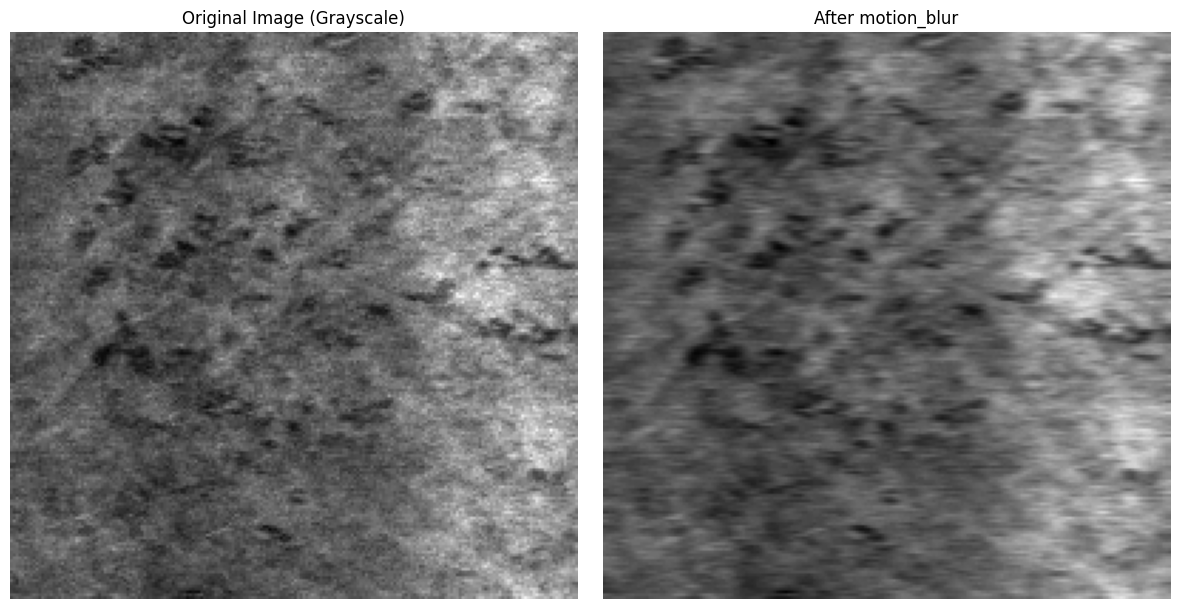

In [6]:
all_images = glob.glob(f"{NEU_ROOT}/train/images/*/rolled-in_scale_225.jpg")

if not all_images:
    print("Not found")
else:
    random_img_path = random.choice(all_images)
    original_img = cv2.imread(random_img_path, cv2.IMREAD_GRAYSCALE)
    processed_img = motion_blur(original_img)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("Original Image (Grayscale)")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(processed_img, cmap='gray')
    plt.title("After motion_blur")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

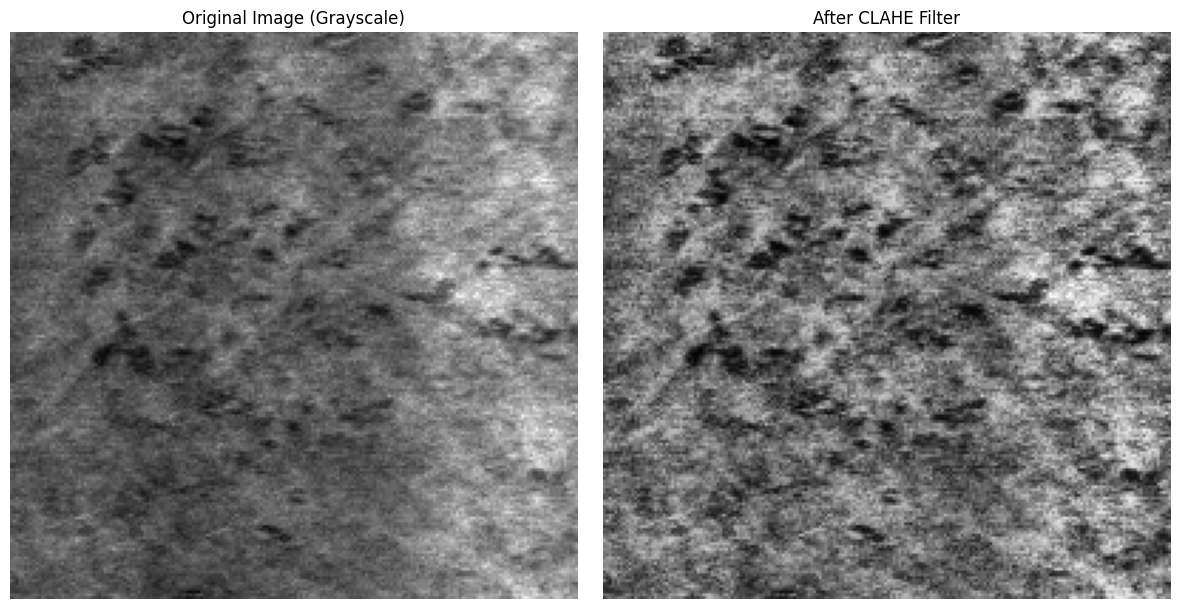

In [7]:
all_images = glob.glob(f"{NEU_ROOT}/train/images/*/rolled-in_scale_225.jpg")

if not all_images:
    print("Not found")
else:
    random_img_path = random.choice(all_images)
    original_img = cv2.imread(random_img_path, cv2.IMREAD_GRAYSCALE)
    processed_img = apply_clahe(original_img)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("Original Image (Grayscale)")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(processed_img, cmap='gray')
    plt.title("After CLAHE Filter")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
def voc_to_yolo(xml_path, img_w, img_h):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    labels = []

    for obj in root.findall("object"):
        cls_name = obj.find("name").text
        cls_id = CLASS_MAP[cls_name]

        b = obj.find("bndbox")
        xmin, ymin = float(b.find("xmin").text), float(b.find("ymin").text)
        xmax, ymax = float(b.find("xmax").text), float(b.find("ymax").text)

        xc = ((xmin + xmax) / 2) / img_w
        yc = ((ymin + ymax) / 2) / img_h
        w = (xmax - xmin) / img_w
        h = (ymax - ymin) / img_h

        labels.append(f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

    return labels

In [7]:
def process_train():
    img_root = f"{NEU_ROOT}/train/images"
    ann_root = f"{NEU_ROOT}/train/annotations"

    for cls in CLASSES:
        img_dir = f"{img_root}/{cls}"
        if not os.path.exists(img_dir): continue

        for img_name in tqdm(os.listdir(img_dir), desc=f"Processing {cls}"):
            img_path = os.path.join(img_dir, img_name)


            base_name = os.path.splitext(img_name)[0]
            xml_path = os.path.join(ann_root, f"{base_name}.xml")

            if not os.path.exists(xml_path):
                continue

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            h, w = img.shape

            img = apply_clahe(img)


            if np.random.rand() < 0.3:
                img = motion_blur(img, k=np.random.choice([3, 5, 7]))

            if np.random.rand() < 0.1:
                sigma = np.random.uniform(2, 10)
                noise = np.random.normal(0, sigma, (h, w)).astype(np.int16)
                img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

            cv2.imwrite(f"{YOLO_ROOT}/images/train/{base_name}.jpg", img)

            labels = voc_to_yolo(xml_path, w, h)
            with open(f"{YOLO_ROOT}/labels/train/{base_name}.txt", "w") as f:
                f.write("\n".join(labels))

In [8]:
def process_val():
    img_root = f"{NEU_ROOT}/validation/images"
    ann_root = f"{NEU_ROOT}/validation/annotations"

    for cls in CLASSES:
        img_dir = f"{img_root}/{cls}"
        if not os.path.exists(img_dir): continue

        for img_name in tqdm(os.listdir(img_dir), desc=f"Val {cls}"):
            img_path = os.path.join(img_dir, img_name)

            base_name = os.path.splitext(img_name)[0]
            xml_path = os.path.join(ann_root, f"{base_name}.xml")

            if not os.path.exists(xml_path):
                continue

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            h, w = img.shape

            img = apply_clahe(img)

            cv2.imwrite(f"{YOLO_ROOT}/images/val/{base_name}.jpg", img)

            labels = voc_to_yolo(xml_path, w, h)
            with open(f"{YOLO_ROOT}/labels/val/{base_name}.txt", "w") as f:
                f.write("\n".join(labels))

In [9]:
print(len(os.listdir(f"{NEU_ROOT}/train/annotations")))
print(len(os.listdir(f"{NEU_ROOT}/validation/annotations")))

1439
361


In [10]:
process_train()
process_val()
print("Dataset Prepared")

Val scratches: 100%|██████████| 60/60 [00:00<00:00, 99.75it/s]

Dataset Prepared


In [11]:
import os
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import os
import zipfile

drive_zip_path = '/content/drive/MyDrive/FINAL_Project/Dataset/NEU_DET_YOLO_Ready.zip'
local_zip_path = '/content/dataset_yolo.zip'
extract_to = YOLO_ROOT

if os.path.exists(drive_zip_path):
    !cp "{drive_zip_path}" {local_zip_path}

else:
    print("Not found")

if not os.path.exists(extract_to):
    os.makedirs(extract_to)

!unzip -q {local_zip_path} -d {extract_to}

!ls {extract_to}

replace dataset_yolo/images/train/inclusion_86.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
images	labels


In [13]:
with open("data.yaml", "w") as f:
    f.write("""
path: dataset_yolo
train: images/train
val: images/val

nc: 6
names:
  - crazing
  - inclusion
  - patches
  - pitted_surface
  - rolled-in_scale
  - scratches
""")


In [14]:
# ============================================================
# YOLO + FUZZY + PPO TRAINING PIPELINE
# ============================================================

# اگر در Colab هستی، این‌ها را نصب کن
!pip install -q ultralytics
!pip install -q stable-baselines3[extra]
!pip install -q gymnasium
!pip install -q scikit-fuzzy
!pip install -q opencv-python matplotlib tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 13.0 MB/s eta 0:00:00


In [15]:
import os
import cv2
import glob
import math
import time
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import deque

from ultralytics import YOLO

import gymnasium as gym
from gymnasium import spaces

import skfuzzy as fuzz
from skfuzzy import control as ctrl

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

warnings.filterwarnings("ignore")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [16]:
def extract_yolo_features(image_path, current_speed, yolo_model):
    img = cv2.imread(image_path)
    if img is None:
        return {
            "max_risk_score": 0.0,
            "mean_confidence": 0.0,
            "defect_count": 0,
            "closest_defect_dist": 1.0
        }

    h, w = img.shape[:2]
    img_blurred = apply_motion_blur(img.copy(), current_speed)
    results = yolo_model(img_blurred, conf=0.25, verbose=False)[0]

    if results.boxes is None or len(results.boxes) == 0:
        return {
            "max_risk_score": 0.0,
            "mean_confidence": 0.0,
            "defect_count": 0,
            "closest_defect_dist": 1.0
        }

    total_pixels = float(h * w)
    confidences = []
    risk_scores = []
    center_distances = []

    img_center_x = w / 2.0
    img_center_y = h / 2.0
    max_possible_dist = np.sqrt(img_center_x**2 + img_center_y**2)

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls[0].cpu().numpy())
        conf = float(box.conf[0].cpu().numpy())

        box_area = max(0.0, (x2 - x1)) * max(0.0, (y2 - y1))
        normalized_area = box_area / total_pixels
        risk_factor = RISK_FACTORS.get(cls_id, 0.5)
        risk_score = min(normalized_area * risk_factor * 10.0, 1.0)

        box_cx = (x1 + x2) / 2.0
        box_cy = (y1 + y2) / 2.0
        dist = np.sqrt((box_cx - img_center_x)**2 + (box_cy - img_center_y)**2)
        normalized_dist = dist / max_possible_dist if max_possible_dist > 0 else 1.0

        confidences.append(conf)
        risk_scores.append(risk_score)
        center_distances.append(normalized_dist)

    return {
        "max_risk_score": float(max(risk_scores)) if risk_scores else 0.0,
        "mean_confidence": float(np.mean(confidences)) if confidences else 0.0,
        "defect_count": int(len(results.boxes)),
        "closest_defect_dist": float(min(center_distances)) if center_distances else 1.0
    }


In [17]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

class AdvancedFuzzyController:
    def __init__(self):
        self.risk_score = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'risk_score')
        self.confidence = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'confidence')
        self.speed_change = ctrl.Consequent(np.arange(-1, 1.01, 0.01), 'speed_change')

        self.risk_score['Low'] = fuzz.gaussmf(self.risk_score.universe, 0, 0.15)
        self.risk_score['Medium'] = fuzz.gaussmf(self.risk_score.universe, 0.5, 0.15)
        self.risk_score['High'] = fuzz.gaussmf(self.risk_score.universe, 1, 0.15)

        self.confidence['Low'] = fuzz.gaussmf(self.confidence.universe, 0, 0.15)
        self.confidence['Medium'] = fuzz.gaussmf(self.confidence.universe, 0.5, 0.15)
        self.confidence['High'] = fuzz.gaussmf(self.confidence.universe, 1, 0.15)

        self.speed_change['Brake'] = fuzz.gaussmf(self.speed_change.universe, -1, 0.25)
        self.speed_change['Maintain'] = fuzz.gaussmf(self.speed_change.universe, 0, 0.15)
        self.speed_change['Accelerate'] = fuzz.gaussmf(self.speed_change.universe, 1, 0.25)

        self.rules = [
            ctrl.Rule(self.risk_score['Low'] & self.confidence['High'], self.speed_change['Accelerate']),
            ctrl.Rule(self.risk_score['Low'] & self.confidence['Medium'], self.speed_change['Accelerate']),
            ctrl.Rule(self.risk_score['Low'] & self.confidence['Low'], self.speed_change['Maintain']),
            ctrl.Rule(self.risk_score['Medium'] & self.confidence['High'], self.speed_change['Brake']),
            ctrl.Rule(self.risk_score['Medium'] & self.confidence['Medium'], self.speed_change['Maintain']),
            ctrl.Rule(self.risk_score['Medium'] & self.confidence['Low'], self.speed_change['Maintain']),
            ctrl.Rule(self.risk_score['High'] & self.confidence['High'], self.speed_change['Brake']),
            ctrl.Rule(self.risk_score['High'] & self.confidence['Medium'], self.speed_change['Brake']),
            ctrl.Rule(self.risk_score['High'] & self.confidence['Low'], self.speed_change['Brake']),
        ]

        self.control_system = ctrl.ControlSystem(self.rules)
        self.simulation = ctrl.ControlSystemSimulation(self.control_system)

    def compute(self, risk_val, conf_val):
        self.simulation.input['risk_score'] = np.clip(risk_val, 0, 1)
        self.simulation.input['confidence'] = np.clip(conf_val, 0, 1)
        self.simulation.compute()
        return self.simulation.output['speed_change']

    def get_label(self, value):
        if value < -0.1:
            return "BRAKE"
        elif value > 0.1:
            return "ACCELERATE"
        return "MAINTAIN"


In [18]:
def apply_motion_blur(image, speed):
    factor = 20
    kernel_size = int(max(1, speed * factor))

    if kernel_size < 2:
        return image

    if kernel_size % 2 == 0:
        kernel_size += 1

    kernel_motion_blur = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    kernel_motion_blur[kernel_size // 2, :] = np.ones(kernel_size, dtype=np.float32)
    kernel_motion_blur /= kernel_size

    return cv2.filter2D(image, -1, kernel_motion_blur)


In [19]:
class DefectSpeedEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, image_paths, yolo_model, fuzzy_controller):
        super().__init__()

        self.image_paths = image_paths
        self.yolo_model = yolo_model
        self.fuzzy_controller = fuzzy_controller

        self.current_idx = 0
        self.current_speed = INITIAL_SPEED
        self.max_steps = len(self.image_paths)
        self.step_count = 0

        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, MIN_SPEED, 0.0, 0.0, -1.0], dtype=np.float32),
            high=np.array([1.0, 1.0, MAX_SPEED, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        # تبدیل اکشن اسپیس به حالت پیوسته (بازه -1 تا 1)
        self.action_space = spaces.Box(
            low=-1.0,
            high=1.0,
            shape=(1,),
            dtype=np.float32
        )

    def _get_observation(self):
        image_path = self.image_paths[self.current_idx]
        features = extract_yolo_features(image_path, self.current_speed, self.yolo_model)

        risk_score = float(features["max_risk_score"])
        mean_conf = float(features["mean_confidence"])
        defect_count = min(float(features["defect_count"]) / float(MAX_DETECTIONS), 1.0)
        closest_dist = float(features["closest_defect_dist"])

        fuzzy_output = float(self.fuzzy_controller.compute(risk_score, mean_conf))

        obs = np.array([
            risk_score,
            mean_conf,
            self.current_speed,
            defect_count,
            closest_dist,
            fuzzy_output
        ], dtype=np.float32)

        return obs, features, fuzzy_output

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_idx = 0
        self.step_count = 0
        self.current_speed = INITIAL_SPEED
        obs, _, _ = self._get_observation()
        return obs, {}

    def step(self, action):
        obs, features, fuzzy_output = self._get_observation()

        prev_speed = self.current_speed
        risk_score = float(features["max_risk_score"])
        mean_conf = float(features["mean_confidence"])

        # استخراج مقدار پیوسته اکشن (کلیپ کردن برای اطمینان از قرارگیری در بازه مجاز)
        action_val = float(np.clip(action[0], -1.0, 1.0))

        # اعمال اکشن پیوسته روی سرعت
        agent_delta = action_val * SPEED_STEP
        self.current_speed = float(np.clip(prev_speed + agent_delta, MIN_SPEED, MAX_SPEED))

        reward = 0.0

        # 1) Fuzzy alignment (Continuous)
        # جریمه بر اساس میزان اختلاف اکشن انتخاب شده با خروجی کنترلر فازی
        reward -= 0.15 * abs(action_val - fuzzy_output)

        # 2) Soft rule-based shaping (Continuous)
        # اگر ریسک بالا باشد، اکشن منفی (کاهش سرعت) پاداش می‌گیرد
        # اگر ریسک پایین باشد، اکشن مثبت (افزایش سرعت) پاداش می‌گیرد
        if risk_score > 0.7:
            reward -= 1.2 * action_val
        elif risk_score < 0.3:
            reward += 0.8 * action_val
        else:
            reward -= 0.4 * abs(action_val) # ترجیح بر حفظ سرعت (اکشن نزدیک به صفر)

        # 3) confidence bonus
        reward += 0.3 * mean_conf

        # 4) continuous speed-risk reward
        reward += 0.5 * self.current_speed * (1.0 - risk_score)
        reward -= 1.5 * risk_score * self.current_speed

        # 5) smoothness penalty
        reward -= 0.3 * abs(self.current_speed - prev_speed)

        self.current_idx += 1
        self.step_count += 1

        terminated = self.current_idx >= self.max_steps
        truncated = False

        if not terminated:
            next_obs, _, _ = self._get_observation()
        else:
            next_obs = obs

        info = {
            "risk_score": risk_score,
            "mean_confidence": mean_conf,
            "fuzzy_output": fuzzy_output,
            "action": action_val,
            "current_speed": self.current_speed,
            "reward": reward
        }

        return next_obs, reward, terminated, truncated, info

    def render(self):
        pass

In [25]:
import os
import cv2
import glob
import time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle
from stable_baselines3 import PPO
from ultralytics import YOLO
from ultralytics.nn.modules import SPPF

RISK_FACTORS = {
    0: 1.0,  # crazing
    1: 0.9,  # inclusion
    2: 0.6,  # patches
    3: 0.8,  # pitted_surface
    4: 0.5,  # rolled-in_scale
    5: 0.2   # scratches
}

# ==========================================
# 1. Custom Blocks (for GSE Model)
# ==========================================
class GSEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.type = "GSE"
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(self.gap(x))

class GSEBlock_Improved(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.gmp = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        avg_out = self.gap(x)
        max_out = self.gmp(x)
        scale = self.fc(avg_out + max_out)
        return x * scale

# ==========================================
# 2. Safe YOLO Loader (Patch / Unpatch)
# ==========================================
def load_yolo_safely(model_name, weights_path):
    # Unpatch SPPF if previously patched
    if hasattr(SPPF, "_gse_patched"):
        SPPF.forward = SPPF._orig_forward
        delattr(SPPF, "_gse_patched")

    if model_name == "YOLO8n_GSE":
        SPPF._orig_forward = SPPF.forward
        def sppf_forward_with_gse(self, x):
            y = SPPF._orig_forward(self, x)
            if not hasattr(self, "gse"):
                self.gse = GSEBlock_Improved(y.shape[1]).to(y.device)
            return self.gse(y)
        SPPF.forward = sppf_forward_with_gse
        SPPF._gse_patched = True

    return YOLO(weights_path)

# ==========================================
# 3. Configurations & Paths
# ==========================================
VAL_IMAGES_DIR = "/content/dataset_yolo/images/val"
SPEED_STEP = 0.1
MIN_SPEED, MAX_SPEED = 0.1, 1.0
INITIAL_SPEED = 0.5

MODELS_CONFIG = {
    "YOLO8n": {
        "yolo": "/content/drive/MyDrive/FINAL_ProjectRc/Training_Results/YOLO_8n_v1/weights/best.pt",
        "ppo": "/content/drive/MyDrive/ppo-yolo8n/PPO_Outputs/best_model/best_model.zip",
        "qlearning": "/content/drive/MyDrive/rl-yolo8n/hybrid_rl_model.pkl"
    },
    "YOLO11m": {
        "yolo": "/content/drive/MyDrive/yolo11medium/best.pt",
        "ppo": "/content/drive/MyDrive/yolo11medium/PPO_Outputs/best_model/best_model.zip",
        "qlearning": "/content/drive/MyDrive/rl-yolo11m/hybrid_rl_model.pkl"
    },
    "YOLO8n_GSE": {
        "yolo": "/content/drive/MyDrive/justgsemodel/best.pt",
        "ppo": "/content/drive/MyDrive/justgsemodel/PPO_Outputs/best_model/best_model.zip",
        "qlearning": "/content/drive/MyDrive/rl-yolojustgse/hybrid_rl_model.pkl"
    },
    "YOLO_Improvement": {
        "yolo": "/content/drive/MyDrive/project-Robotic/best.pt",
        "ppo": "/content/drive/MyDrive/project-Robotic/PPO_Outputs/best_model/best_model.zip",
        "qlearning": "/content/drive/MyDrive/rl-yoloimprovement/hybrid_rl_model.pkl"
    }
}

image_paths = sorted(
    glob.glob(os.path.join(VAL_IMAGES_DIR, "**", "*.jpg"), recursive=True) +
    glob.glob(os.path.join(VAL_IMAGES_DIR, "**", "*.png"), recursive=True)
)

fuzzy_brain = AdvancedFuzzyController()

# ==========================================
# 4. Benchmarking Logic
# ==========================================
def get_qlearning_action(q_table, speed, fuzzy_out):
    # Mapping to discrete states (as per your summary)
    speed_state = 0 if speed < 0.4 else (2 if speed > 0.7 else 1)
    fuzzy_state = 0 if fuzzy_out < -0.1 else (2 if fuzzy_out > 0.1 else 1)
    # Greedy action selection (epsilon=0)
    action = int(np.argmax(q_table[fuzzy_state, speed_state]))
    return action

def run_benchmark(model_name, yolo_model, rl_type, rl_model):
    speed = INITIAL_SPEED
    total_risk, total_speed = 0.0, 0.0
    start_time = time.time()

    for img_path in image_paths:
        features = extract_yolo_features(img_path, speed, yolo_model)
        risk = float(features["max_risk_score"])
        conf = float(features["mean_confidence"])
        fuzzy_out = float(fuzzy_brain.compute(risk, conf))

        # Determine Action based on RL Type
        if rl_type == "PPO":
            obs = np.array([risk, conf, speed, features["defect_count"]/10.0, features["closest_defect_dist"], fuzzy_out], dtype=np.float32)
            action, _ = rl_model.predict(obs, deterministic=True)
            action = int(action)
        elif rl_type == "QLearning":
            action = get_qlearning_action(rl_model, speed, fuzzy_out)

        # Apply Action
        agent_delta = -SPEED_STEP if action == 0 else (SPEED_STEP if action == 2 else 0.0)
        speed = float(np.clip(speed + agent_delta, MIN_SPEED, MAX_SPEED))

        total_risk += risk
        total_speed += speed

    end_time = time.time()
    num_frames = len(image_paths)

    return {
        "Model": model_name,
        "RL_Agent": rl_type,
        "Mean_Speed": total_speed / num_frames,
        "Mean_Risk": total_risk / num_frames,
        "FPS": num_frames / (end_time - start_time)
    }

# ==========================================
# 5. Execution & Reporting
# ==========================================
results = []

for model_name, paths in MODELS_CONFIG.items():
    print(f"\nEvaluating: {model_name}")

    # 1. Load YOLO
    yolo_model = load_yolo_safely(model_name, paths["yolo"])

    # 2. Evaluate with PPO
    print(f"  -> Running PPO...")
    ppo_agent = PPO.load(paths["ppo"])
    res_ppo = run_benchmark(model_name, yolo_model, "PPO", ppo_agent)
    results.append(res_ppo)

    # 3. Evaluate with Q-Learning
    print(f"  -> Running Q-Learning...")
    with open(paths["qlearning"], "rb") as f:
        q_table = pickle.load(f)
    res_q = run_benchmark(model_name, yolo_model, "QLearning", q_table)
    results.append(res_q)

# Create DataFrame and Save
df_benchmark = pd.DataFrame(results)
print("\n=== Benchmark Results ===")
print(df_benchmark.to_string(index=False))
df_benchmark.to_csv("/content/drive/MyDrive/benchmark_results.csv", index=False)
print("\nResults saved to /content/drive/MyDrive/benchmark_results.csv")


Evaluating: YOLO8n
  -> Running PPO...
  -> Running Q-Learning...

Evaluating: YOLO11m
  -> Running PPO...
  -> Running Q-Learning...

Evaluating: YOLO8n_GSE
  -> Running PPO...
  -> Running Q-Learning...

Evaluating: YOLO_Improvement
  -> Running PPO...
  -> Running Q-Learning...

=== Benchmark Results ===
           Model  RL_Agent  Mean_Speed  Mean_Risk      FPS
          YOLO8n       PPO    0.106667   0.826483 4.053351
          YOLO8n QLearning    0.241389   0.825670 4.135968
         YOLO11m       PPO    0.233056   0.688396 0.636629
         YOLO11m QLearning    0.238889   0.788984 0.643489
      YOLO8n_GSE       PPO    0.113333   0.811042 4.087222
      YOLO8n_GSE QLearning    0.241667   0.811749 4.060067
YOLO_Improvement       PPO    0.299722   0.630290 4.067605
YOLO_Improvement QLearning    0.234722   0.737670 4.108750

Results saved to /content/drive/MyDrive/benchmark_results.csv


In [20]:
import os
import cv2
import glob
import time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle
from stable_baselines3 import PPO
from ultralytics import YOLO
from ultralytics.nn.modules import SPPF

RISK_FACTORS = {
    0: 1.0,  # crazing
    1: 0.9,  # inclusion
    2: 0.6,  # patches
    3: 0.8,  # pitted_surface
    4: 0.5,  # rolled-in_scale
    5: 0.2   # scratches
}

# ==========================================
# 1. Custom Blocks (for GSE Model)
# ==========================================
class GSEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.type = "GSE"
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(self.gap(x))

class GSEBlock_Improved(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.gmp = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        avg_out = self.gap(x)
        max_out = self.gmp(x)
        scale = self.fc(avg_out + max_out)
        return x * scale

# ==========================================
# 2. Safe YOLO Loader (Patch / Unpatch)
# ==========================================
def load_yolo_safely(model_name, weights_path):
    # Unpatch SPPF if previously patched
    if hasattr(SPPF, "_gse_patched"):
        SPPF.forward = SPPF._orig_forward
        delattr(SPPF, "_gse_patched")

    if model_name == "YOLO8n_GSE":
        SPPF._orig_forward = SPPF.forward
        def sppf_forward_with_gse(self, x):
            y = SPPF._orig_forward(self, x)
            if not hasattr(self, "gse"):
                self.gse = GSEBlock_Improved(y.shape[1]).to(y.device)
            return self.gse(y)
        SPPF.forward = sppf_forward_with_gse
        SPPF._gse_patched = True

    return YOLO(weights_path)

# ==========================================
# 3. Configurations & Paths
# ==========================================
VAL_IMAGES_DIR = "/content/dataset_yolo/images/val"
SPEED_STEP = 0.1
MIN_SPEED, MAX_SPEED = 0.1, 1.0
INITIAL_SPEED = 0.5

MODELS_CONFIG = {
    "YOLO8n": {
        "yolo": "/content/drive/MyDrive/FINAL_ProjectRc/Training_Results/YOLO_8n_v1/weights/best.pt",
        "ppo": "/content/drive/MyDrive/ppo-yolo8n/PPO_Outputs/best_model/best_model.zip",
        "qlearning": "/content/drive/MyDrive/rl-yolo8n/hybrid_rl_model.pkl"
    },
    "YOLO11m": {
        "yolo": "/content/drive/MyDrive/yolo11medium/best.pt",
        "ppo": "/content/drive/MyDrive/yolo11medium/PPO_Outputs/best_model/best_model.zip",
        "qlearning": "/content/drive/MyDrive/rl-yolo11m/hybrid_rl_model.pkl"
    },
    "YOLO8n_GSE": {
        "yolo": "/content/drive/MyDrive/justgsemodel/best.pt",
        "ppo": "/content/drive/MyDrive/justgsemodel/PPO_Outputs/best_model/best_model.zip",
        "qlearning": "/content/drive/MyDrive/rl-yolojustgse/hybrid_rl_model.pkl"
    },
    "YOLO_Improvement": {
        "yolo": "/content/drive/MyDrive/project-Robotic/best.pt",
        "ppo": "/content/drive/MyDrive/project-Robotic/PPO_Outputs/best_model/best_model.zip",
        "qlearning": "/content/drive/MyDrive/rl-yoloimprovement/hybrid_rl_model.pkl"
    }
}

image_paths = sorted(
    glob.glob(os.path.join(VAL_IMAGES_DIR, "**", "*.jpg"), recursive=True) +
    glob.glob(os.path.join(VAL_IMAGES_DIR, "**", "*.png"), recursive=True)
)

fuzzy_brain = AdvancedFuzzyController()

# ==========================================
# 4. Benchmarking Logic
# ==========================================
def get_qlearning_action(q_table, speed, fuzzy_out):
    # Mapping to discrete states (as per your summary)
    speed_state = 0 if speed < 0.4 else (2 if speed > 0.7 else 1)
    fuzzy_state = 0 if fuzzy_out < -0.1 else (2 if fuzzy_out > 0.1 else 1)
    # Greedy action selection (epsilon=0)
    action = int(np.argmax(q_table[fuzzy_state, speed_state]))
    return action

def run_benchmark(model_name, yolo_model, rl_type, rl_model):
    speed = INITIAL_SPEED
    total_risk, total_speed = 0.0, 0.0
    start_time = time.time()

    for img_path in image_paths:
        features = extract_yolo_features(img_path, speed, yolo_model)
        risk = float(features["max_risk_score"])
        conf = float(features["mean_confidence"])
        fuzzy_out = float(fuzzy_brain.compute(risk, conf))

        # Determine Action based on RL Type
        if rl_type == "PPO":
            obs = np.array([risk, conf, speed, features["defect_count"]/10.0, features["closest_defect_dist"], fuzzy_out], dtype=np.float32)
            action, _ = rl_model.predict(obs, deterministic=True)
            action = int(action)
        elif rl_type == "QLearning":
            action = get_qlearning_action(rl_model, speed, fuzzy_out)

        # Apply Action
        agent_delta = -SPEED_STEP if action == 0 else (SPEED_STEP if action == 2 else 0.0)
        speed = float(np.clip(speed + agent_delta, MIN_SPEED, MAX_SPEED))

        total_risk += risk
        total_speed += speed

    end_time = time.time()
    num_frames = len(image_paths)

    return {
        "Model": model_name,
        "RL_Agent": rl_type,
        "Mean_Speed": total_speed / num_frames,
        "Mean_Risk": total_risk / num_frames,
        "FPS": num_frames / (end_time - start_time)
    }

# ==========================================
# 5. Execution & Reporting
# ==========================================
results = []

for model_name, paths in MODELS_CONFIG.items():
    print(f"\nEvaluating: {model_name}")

    # 1. Load YOLO
    yolo_model = load_yolo_safely(model_name, paths["yolo"])

    # 2. Evaluate with PPO
    print(f"  -> Running PPO...")
    ppo_agent = PPO.load(paths["ppo"])
    res_ppo = run_benchmark(model_name, yolo_model, "PPO", ppo_agent)
    results.append(res_ppo)

    # 3. Evaluate with Q-Learning
    print(f"  -> Running Q-Learning...")
    with open(paths["qlearning"], "rb") as f:
        q_table = pickle.load(f)
    res_q = run_benchmark(model_name, yolo_model, "QLearning", q_table)
    results.append(res_q)

# Create DataFrame and Save
df_benchmark = pd.DataFrame(results)
print("\n=== Benchmark Results ===")
print(df_benchmark.to_string(index=False))
df_benchmark.to_csv("/content/drive/MyDrive/benchmark_resultsGPU.csv", index=False)
print("\nResults saved to /content/drive/MyDrive/benchmark_resultsGPU.csv")


Evaluating: YOLO8n
  -> Running PPO...
  -> Running Q-Learning...

Evaluating: YOLO11m
  -> Running PPO...
  -> Running Q-Learning...

Evaluating: YOLO8n_GSE
  -> Running PPO...
  -> Running Q-Learning...

Evaluating: YOLO_Improvement
  -> Running PPO...
  -> Running Q-Learning...

=== Benchmark Results ===
           Model  RL_Agent  Mean_Speed  Mean_Risk       FPS
          YOLO8n       PPO    0.106667   0.826483 38.685694
          YOLO8n QLearning    0.241389   0.825670 79.172426
         YOLO11m       PPO    0.233056   0.688396 32.604057
         YOLO11m QLearning    0.238889   0.788984 33.736987
      YOLO8n_GSE       PPO    0.113333   0.811042 53.510377
      YOLO8n_GSE QLearning    0.241667   0.811749 56.174235
YOLO_Improvement       PPO    0.299722   0.630290 57.194639
YOLO_Improvement QLearning    0.234722   0.737670 63.624018

Results saved to /content/drive/MyDrive/benchmark_resultsGPU.csv
